In [1]:
import os
os.getcwd()

'd:\\Programming\\labwork\\cv_labexam'

### Arithmetic and Geometric Filters are good for Gaussian noise

In [4]:
import numpy as np
import cv2

img_dir = os.path.join(os.getcwd(), "data", "images", "circuit.png")
img = cv2.imread(img_dir) / 255.0
mean = 0
std = 0.1
noise = np.random.normal(mean, std, img.shape)
noisy_image = img + noise
noisy_image = np.clip(noisy_image, 0, 1)

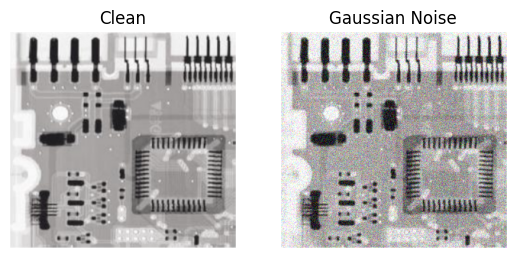

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].imshow(img)
axes[0].set_title("Clean")
axes[0].axis("off")
axes[1].imshow(noisy_image)
axes[1].set_title("Gaussian Noise")
axes[1].axis("off")

plt.show()

In [13]:
def arithmetic_mean_filter(image, kernel=3):
    pad = kernel // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kernel, j:j + kernel]
            output[i, j] = np.mean(region)
    return output

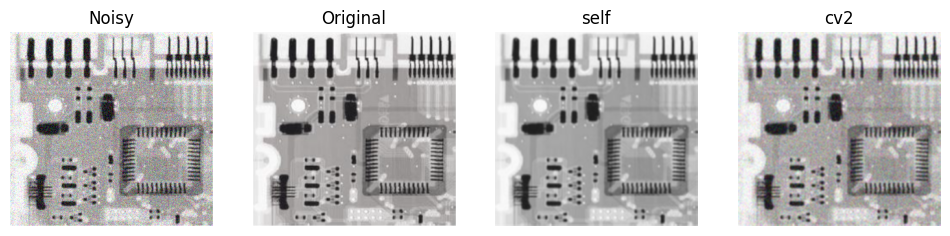

In [17]:
recon = arithmetic_mean_filter(noisy_image)
recon_cv = cv2.blur(noisy_image, (3, 3))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("self")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [12]:
img.shape

(284, 296, 3)

In [18]:
def geometric_mean_filter(image, kernel=3):
    pad = kernel // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kernel, j:j + kernel]
            
            region = np.where(region == 0, 1e-6, region)
            log_region = np.log(region)
            mean_log = np.mean(log_region)
            output[i, j] = np.exp(mean_log)
    return output

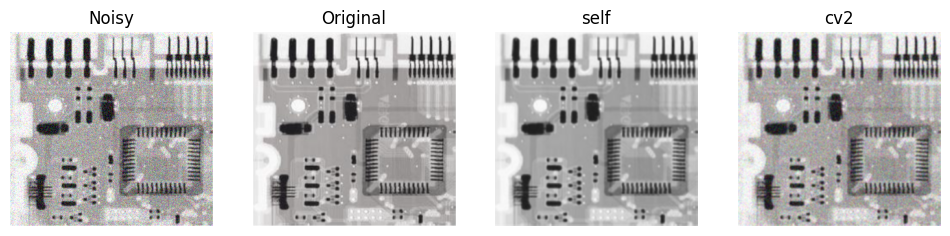

In [20]:
recon = geometric_mean_filter(noisy_image)
recon_cv = cv2.GaussianBlur(noisy_image, (3, 3), 0)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("self")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [28]:
def add_salt_pepper_noise(image, prob=0.05, salt=True, pepper=True):
    noisy = image.copy()
    if salt:
        salt_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[salt_mask] = 255

    if pepper: 
        pepper_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[pepper_mask] = 0
    return noisy

In [54]:
def median_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.median(region)
    
    return output

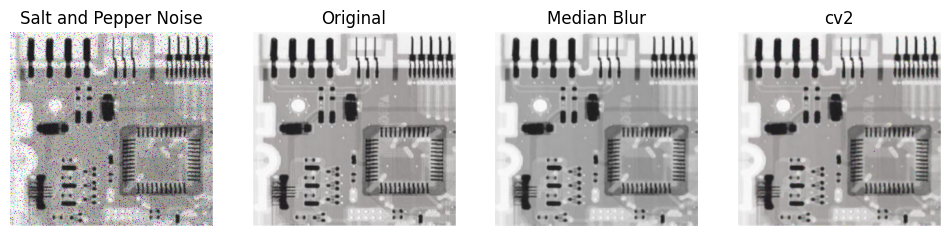

In [73]:
noisy_image = add_salt_pepper_noise(img)
recon = median_filter(noisy_image, 3)
noisy_image = (noisy_image * 255).astype('uint8')
recon_cv = cv2.medianBlur(noisy_image, 3)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Salt and Pepper Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Median Blur")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [63]:
def max_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.max(region)
    
    return output

def min_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.min(region)
    
    return output

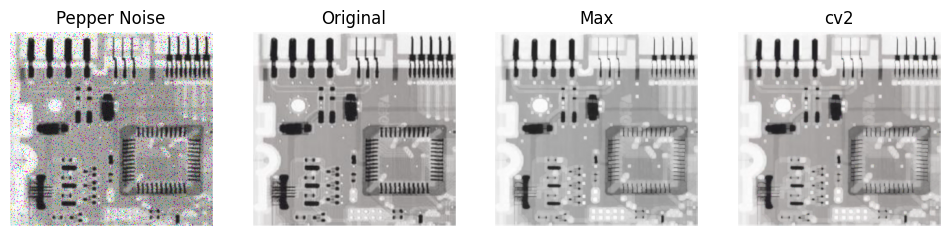

In [74]:
noisy_image = add_salt_pepper_noise(img, prob=0.1, salt=False)
recon = max_filter(noisy_image, 3)
# noisy_image = (noisy_image * 255).astype('uint8')
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
recon_cv = cv2.dilate(noisy_image, kernel)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Pepper Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Max")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08627450980392157..255.0].


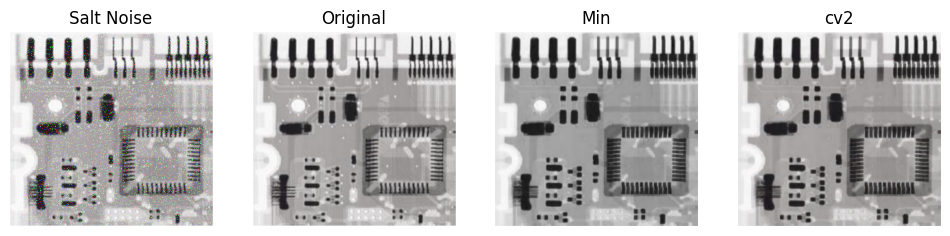

In [78]:
noisy_image = add_salt_pepper_noise(img, prob=0.1, pepper=False)
recon = min_filter(noisy_image, 3)
# noisy_image = (noisy_image * 255).astype('uint8')
kernel = np.ones((3, 3), np.uint8)
recon_cv = cv2.erode(noisy_image, kernel, iterations=1)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Salt Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Min")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()